# vLLM Benchmark Results Analysis
Visualize output from `run_benchmark.py`: Cold / Warm / Long Context phases.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "SimHei"],
    "axes.unicode_minus": False,
    "figure.dpi": 120,
})

# Load the latest benchmark result CSV
result_files = sorted(glob.glob("results/benchmark_*.csv"))
if not result_files:
    raise FileNotFoundError("No benchmark result CSV found in results/. Run run_benchmark.py first.")

csv_path = result_files[-1]
print(f"Loading: {csv_path}")
df = pd.read_csv(csv_path)
df.head(10)


Loading: results/benchmark_20260220_151345.csv


,phase,label,input_tokens,output_tokens,ttft_ms,latency_ms,decode_tps,gpu_mem_peak_mb,success,error,timestamp
0,cold,first_request,81,256,232.027916,9151.847009,28.588024,22001.0,True,NaN,2026-02-20T15:03:07.823024+00:00
1,concurrent_scaling,c1_r1_req1,4096,256,1075.900296,10133.027361,28.154623,22001.0,True,NaN,2026-02-20T15:03:27.388519+00:00
2,concurrent_scaling,c1_r2_req1,4096,256,1075.332182,10156.877223,28.078923,22001.0,True,NaN,2026-02-20T15:03:47.932775+00:00
3,concurrent_scaling,c1_r3_req1,4096,252,1075.290673,9999.061978,28.127122,22001.0,True,NaN,2026-02-20T15:04:08.433235+00:00
4,concurrent_scaling,c2_r1_req1,4096,256,1103.734527,11685.157885,24.098837,22001.0,True,NaN,2026-02-20T15:04:39.319638+00:00
5,concurrent_scaling,c2_r1_req2,4096,234,2135.044415,10972.729839,26.364369,22001.0,True,NaN,2026-02-20T15:04:39.320768+00:00
6,concurrent_scaling,c2_r2_req1,4096,238,1106.787293,11052.352244,23.829717,22001.0,True,NaN,2026-02-20T15:05:11.639196+00:00
7,concurrent_scaling,c2_r2_req2,4096,256,2138.785407,11761.686882,26.499284,22001.0,True,NaN,2026-02-20T15:05:11.640303+00:00
8,concurrent_scaling,c2_r3_req1,4096,256,1103.908883,11720.637126,24.018699,22001.0,True,NaN,2026-02-20T15:05:43.995645+00:00
9,concurrent_scaling,c2_r3_req2,4096,250,2136.444185,11576.636286,26.376582,22001.0,True,NaN,2026-02-20T15:05:43.996741+00:00


In [3]:
# Phase A: Cold Start
cold = df[df["phase"] == "cold"]
if not cold.empty:
    r = cold.iloc[0]
    print("=== Phase A: Cold Start ===")
    print(f"  TTFT         : {r['ttft_ms']:.1f} ms")
    print(f"  Total latency: {r['latency_ms']:.1f} ms")
    print(f"  Decode TPS   : {r['decode_tps']:.1f} tokens/s")
    print(f"  GPU mem peak : {r['gpu_mem_peak_mb']:.0f} MB")

=== Phase A: Cold Start ===
  TTFT         : 285.2 ms
  Total latency: 9196.6 ms
  Decode TPS   : 28.6 tokens/s
  GPU mem peak : 20849 MB


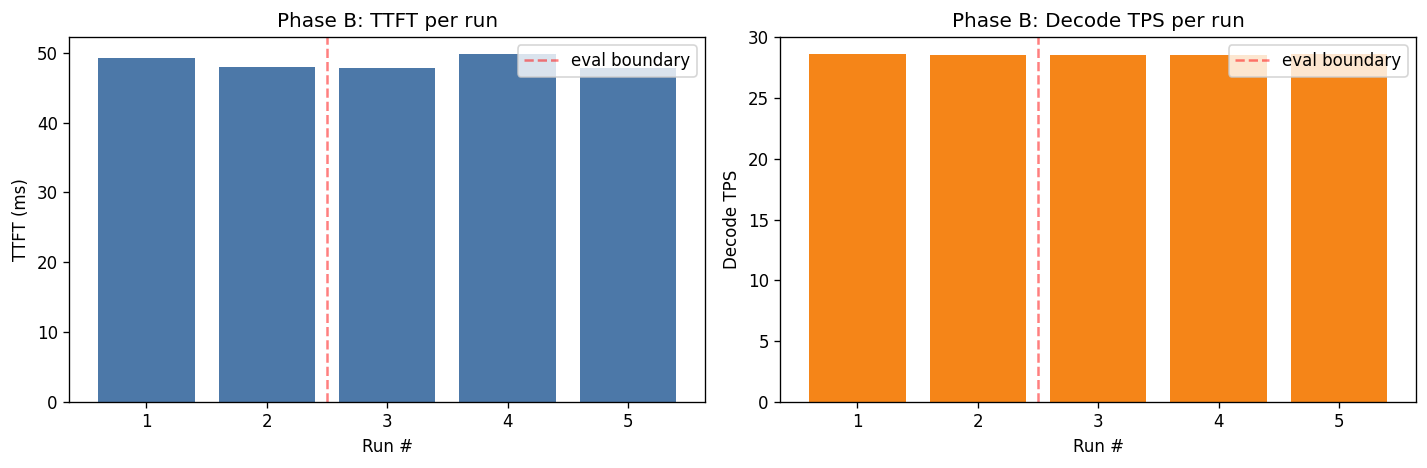

=== Phase B: Eval Runs (3-5) ===
  TTFT  p50=47.8ms  p95=49.6ms
  TPS   p50=28.6  p95=28.6


In [4]:
# Phase B: Warm Start — TTFT & TPS across runs
warm = df[df["phase"] == "warm"].copy()
if not warm.empty:
    warm["run"] = range(1, len(warm) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.bar(warm["run"], warm["ttft_ms"], color="#4C78A8")
    ax1.set_xlabel("Run #")
    ax1.set_ylabel("TTFT (ms)")
    ax1.set_title("Phase B: TTFT per run")
    ax1.axvline(x=2.5, color="red", linestyle="--", alpha=0.5, label="eval boundary")
    ax1.legend()

    ax2.bar(warm["run"], warm["decode_tps"], color="#F58518")
    ax2.set_xlabel("Run #")
    ax2.set_ylabel("Decode TPS")
    ax2.set_title("Phase B: Decode TPS per run")
    ax2.axvline(x=2.5, color="red", linestyle="--", alpha=0.5, label="eval boundary")
    ax2.legend()

    plt.tight_layout()
    plt.savefig("results/phase_b_warm.png", bbox_inches="tight")
    plt.show()

    # P50/P95 for eval runs (3-5)
    eval_runs = warm[warm["run"] >= 3]
    print("=== Phase B: Eval Runs (3-5) ===")
    print(f"  TTFT  p50={eval_runs['ttft_ms'].quantile(0.5):.1f}ms  p95={eval_runs['ttft_ms'].quantile(0.95):.1f}ms")
    print(f"  TPS   p50={eval_runs['decode_tps'].quantile(0.5):.1f}  p95={eval_runs['decode_tps'].quantile(0.95):.1f}")

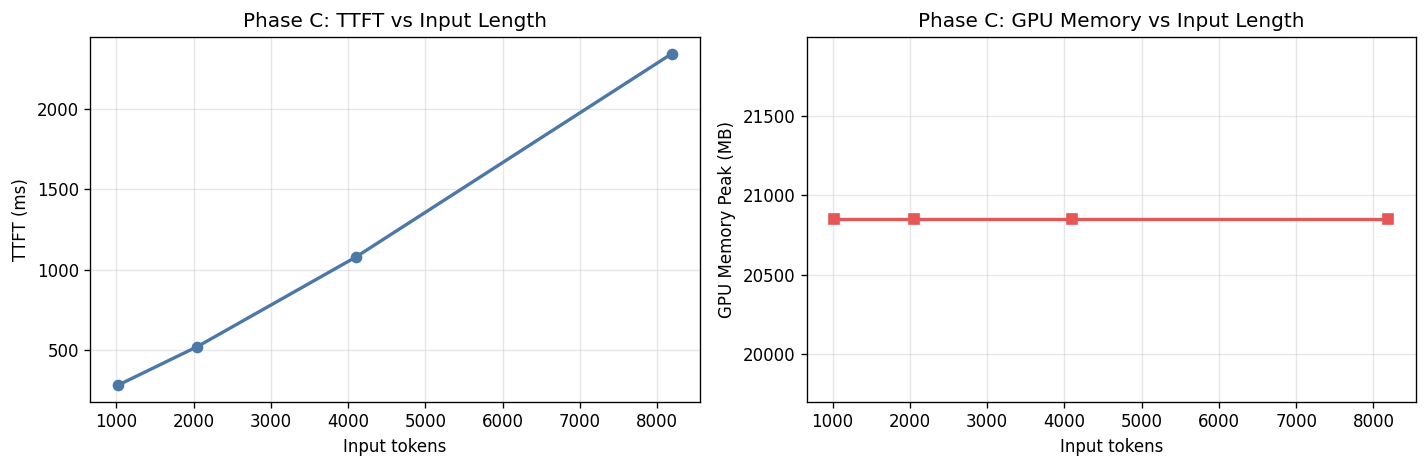

=== Phase C: Long Context Details ===
     label  input_tokens     ttft_ms  decode_tps  gpu_mem_peak_mb
input_1024          1024  285.388240   28.503577          20849.0
input_2048          2048  523.881519   28.259385          20849.0
input_4096          4096 1078.179900   28.091688          20849.0
input_8192          8192 2341.412683   27.559653          20849.0


In [5]:
# Phase C: Long Context — TTFT & GPU memory vs input length
lc = df[df["phase"] == "long_context"].copy()
if not lc.empty:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(lc["input_tokens"], lc["ttft_ms"], marker="o", color="#4C78A8", linewidth=2)
    ax1.set_xlabel("Input tokens")
    ax1.set_ylabel("TTFT (ms)")
    ax1.set_title("Phase C: TTFT vs Input Length")
    ax1.grid(True, alpha=0.3)

    ax2.plot(lc["input_tokens"], lc["gpu_mem_peak_mb"], marker="s", color="#E45756", linewidth=2)
    ax2.set_xlabel("Input tokens")
    ax2.set_ylabel("GPU Memory Peak (MB)")
    ax2.set_title("Phase C: GPU Memory vs Input Length")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/phase_c_long_context.png", bbox_inches="tight")
    plt.show()

    print("=== Phase C: Long Context Details ===")
    print(lc[["label", "input_tokens", "ttft_ms", "decode_tps", "gpu_mem_peak_mb"]].to_string(index=False))

In [6]:
# Full summary table
print("=== Full Benchmark Results ===")
print(df[["phase", "label", "input_tokens", "output_tokens", "ttft_ms", "decode_tps", "gpu_mem_peak_mb", "success"]].to_string(index=False))

=== Full Benchmark Results ===
       phase         label  input_tokens  output_tokens     ttft_ms  decode_tps  gpu_mem_peak_mb  success
        cold first_request            81            256  285.151756   28.614806          20849.0     True
        warm         run_1            81            256   49.278864   28.595665          20849.0     True
        warm         run_2            81            256   47.911893   28.591565          20849.0     True
        warm         run_3            81            256   47.758630   28.556168          20849.0     True
        warm         run_4            81            256   49.764162   28.587742          20849.0     True
        warm         run_5            81            256   47.796931   28.605225          20849.0     True
long_context    input_1024          1024            128  285.388240   28.503577          20849.0     True
long_context    input_2048          2048            128  523.881519   28.259385          20849.0     True
long_context   

## Phase E: Concurrency Scaling
Per-request TTFT / decode TPS vs concurrency level, plus aggregate throughput.

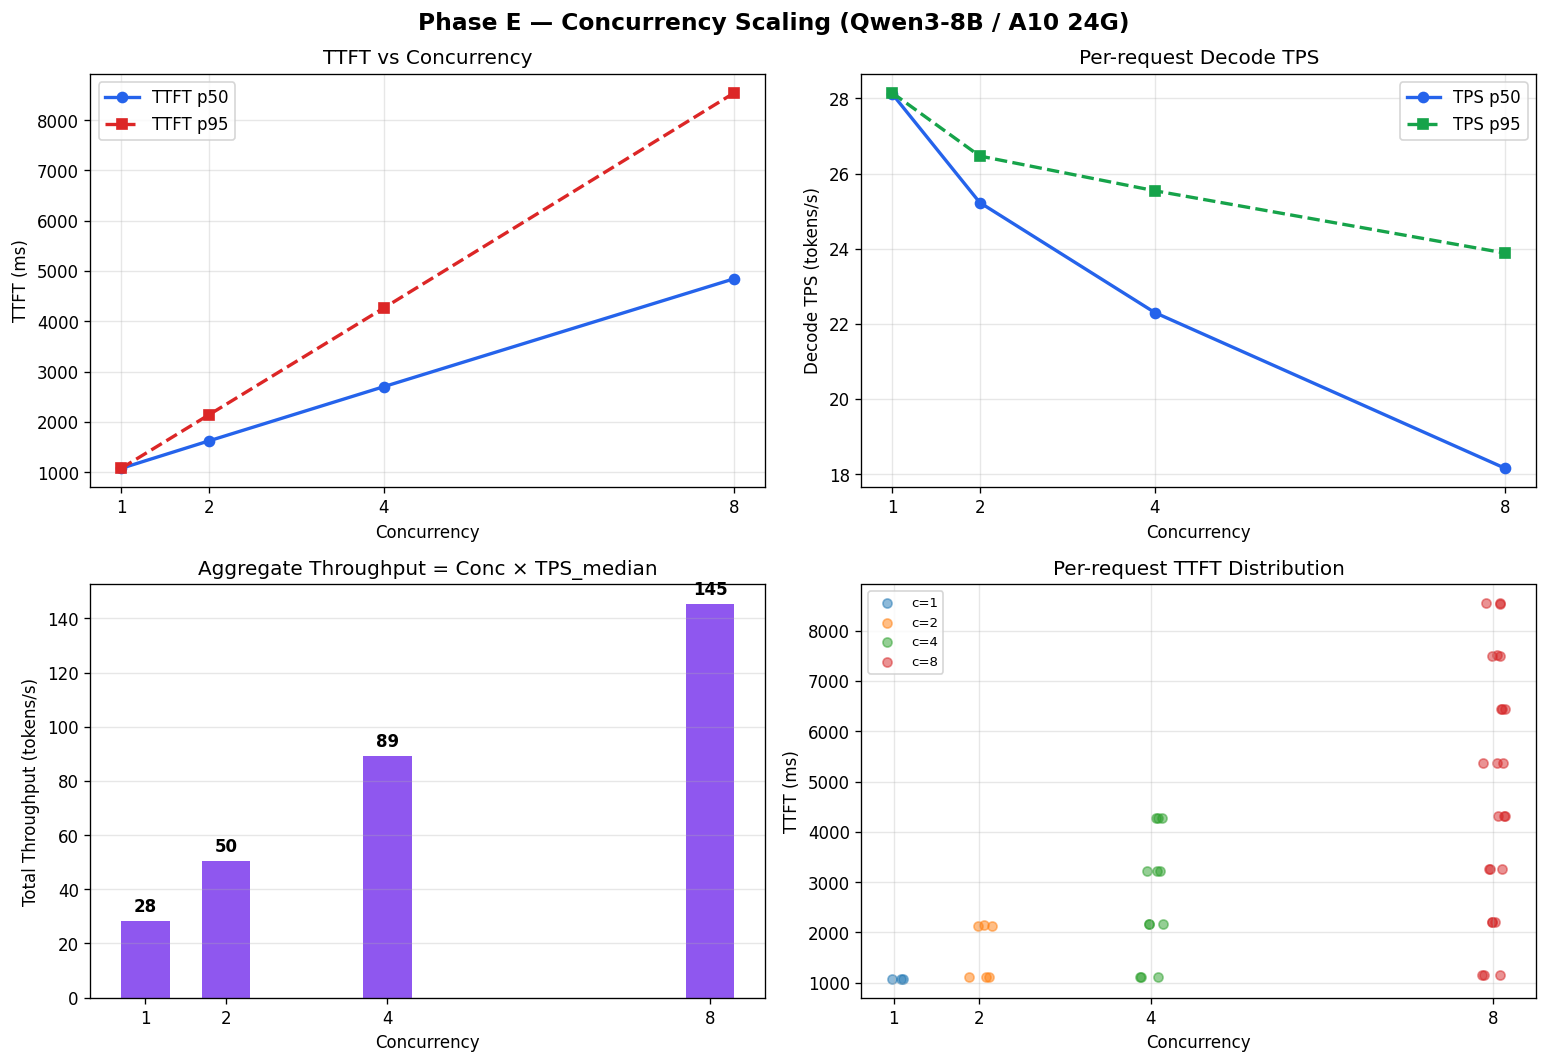


=== Phase E Summary ===
 concurrency    ttft_p50    ttft_p95   tps_p50   tps_p95  total_throughput  gpu_mem_peak_mb  n_requests
           1 1075.332182 1075.843485 28.127122 28.151873         28.127122          22001.0           3
           2 1620.915854 2138.200101 25.231603 26.468609         50.463206          22001.0           6
           4 2700.797934 4265.987968 22.301137 25.543800         89.204546          22001.0          12
           8 4847.021912 8543.194121 18.156033 23.884869        145.248261          22001.0          24

Saved: results/phase_e_concurrency_scaling.png


In [3]:
import re
import numpy as np

ce = df[df["phase"] == "concurrent_scaling"].copy()
if ce.empty:
    print("No concurrent_scaling data found — skipping Phase E charts.")
else:
    ce["concurrency"] = ce["label"].apply(lambda s: int(re.search(r"c(\d+)_", s).group(1)))

    levels = sorted(ce["concurrency"].unique())

    # Aggregate per concurrency level
    rows = []
    for c in levels:
        sub = ce[ce["concurrency"] == c]
        ttfts = sub["ttft_ms"].values
        tps_vals = sub["decode_tps"].values
        rows.append({
            "concurrency": c,
            "ttft_p50": np.percentile(ttfts, 50),
            "ttft_p95": np.percentile(ttfts, 95),
            "tps_p50": np.percentile(tps_vals, 50),
            "tps_p95": np.percentile(tps_vals, 95),
            "total_throughput": c * np.median(tps_vals),
            "gpu_mem_peak_mb": sub["gpu_mem_peak_mb"].max(),
            "n_requests": len(sub),
        })
    summary = pd.DataFrame(rows)

    # ---- Figure: 2×2 grid ----
    fig, axes = plt.subplots(2, 2, figsize=(13, 9))
    fig.suptitle("Phase E — Concurrency Scaling (Qwen3-8B / A10 24G)", fontsize=14, fontweight="bold")

    x = summary["concurrency"]

    # (0,0) TTFT p50 / p95
    ax = axes[0, 0]
    ax.plot(x, summary["ttft_p50"], "o-", color="#2563eb", label="TTFT p50", linewidth=2)
    ax.plot(x, summary["ttft_p95"], "s--", color="#dc2626", label="TTFT p95", linewidth=2)
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("TTFT (ms)")
    ax.set_title("TTFT vs Concurrency")
    ax.set_xticks(levels)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # (0,1) Per-request decode TPS p50 / p95
    ax = axes[0, 1]
    ax.plot(x, summary["tps_p50"], "o-", color="#2563eb", label="TPS p50", linewidth=2)
    ax.plot(x, summary["tps_p95"], "s--", color="#16a34a", label="TPS p95", linewidth=2)
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("Decode TPS (tokens/s)")
    ax.set_title("Per-request Decode TPS")
    ax.set_xticks(levels)
    ax.legend()
    ax.grid(True, alpha=0.3)

    # (1,0) Aggregate throughput
    ax = axes[1, 0]
    bars = ax.bar(x, summary["total_throughput"], color="#7c3aed", width=0.6, alpha=0.85)
    for bar, val in zip(bars, summary["total_throughput"]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                f"{val:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("Total Throughput (tokens/s)")
    ax.set_title("Aggregate Throughput = Conc × TPS_median")
    ax.set_xticks(levels)
    ax.grid(True, alpha=0.3, axis="y")

    # (1,1) Scatter: per-request TTFT distribution by concurrency
    ax = axes[1, 1]
    for c in levels:
        sub = ce[ce["concurrency"] == c]
        jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(sub))
        ax.scatter(c + jitter, sub["ttft_ms"], alpha=0.5, s=30, label=f"c={c}")
    ax.set_xlabel("Concurrency")
    ax.set_ylabel("TTFT (ms)")
    ax.set_title("Per-request TTFT Distribution")
    ax.set_xticks(levels)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/phase_e_concurrency_scaling.png", dpi=150, bbox_inches="tight")
    plt.show()

    print("\n=== Phase E Summary ===")
    print(summary.to_string(index=False))
    print(f"\nSaved: results/phase_e_concurrency_scaling.png")